<a href="https://colab.research.google.com/github/gureozgenur/surucu-dikkat-tespiti/blob/main/surucu_dikkat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
zip_path = "/content/archive.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP açıldı ✅")

ZIP açıldı ✅


In [ ]:
import os

os.listdir("/content/")

['.config', 'data', 'archive.zip', 'drive', 'sample_data']

In [ ]:
os.listdir("/content/data")



['split_data.py',
 'test',
 'get_info.py',
 'readme.md',
 'train',
 'labels.txt',
 'val']

In [ ]:
import os

print("train:", os.listdir("/content/data/train"))
print("val:", os.listdir("/content/data/val"))
print("test:", os.listdir("/content/data/test"))

train: ['awake', 'sleepy']
val: ['awake', 'sleepy']
test: ['awake', 'sleepy']


In [ ]:
with open("/content/data/labels.txt", "r", encoding="utf-8") as f:
    print(f.read())


awake
sleepy



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (96, 96)
batch_size = 32

train_dir = "/content/data/train"
val_dir = "/content/data/val"
test_dir = "/content/data/test"

train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 50937 images belonging to 2 classes.


In [ ]:
print(train_data.class_indices)

{'awake': 0, 'sleepy': 1}


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (96, 96)
batch_size = 32

train_dir = "/content/data/train"
val_dir = "/content/data/val"
test_dir = "/content/data/test"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print(train_data.class_indices)

Found 50937 images belonging to 2 classes.
Found 16980 images belonging to 2 classes.
Found 16981 images belonging to 2 classes.
{'awake': 0, 'sleepy': 1}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,905 (6.61 MB)

 Trainable params: 1,731,905 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

labels = train_data.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9883003492433061), 1: np.float64(1.0119799737751818)}


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

In [ ]:
import os

print("awake:", len(os.listdir("/content/data/train/awake")))
print("sleepy:", len(os.listdir("/content/data/train/sleepy")))

awake: 25770
sleepy: 25167


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_stop, lr_reduce],
)

Epoch 1/100
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.9195 - loss: 0.2062 - val_accuracy: 0.9646 - val_loss: 0.0990 - learning_rate: 0.0010
Epoch 2/100
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9667 - loss: 0.0966 - val_accuracy: 0.9792 - val_loss: 0.0664 - learning_rate: 0.0010
Epoch 3/100
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9751 - loss: 0.0717 - val_accuracy: 0.9810 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 4/100
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9794 - loss: 0.0579 - val_accuracy: 0.9845 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 5/100
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9820 - loss: 0.0504 - val_accuracy: 0.9850 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 6/100
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9833 - loss: 0.0470 - val_accuracy: 0.9841 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 7/100
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step -

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

531/531 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9898 - loss: 0.0329
Test Accuracy: 0.9898121356964111


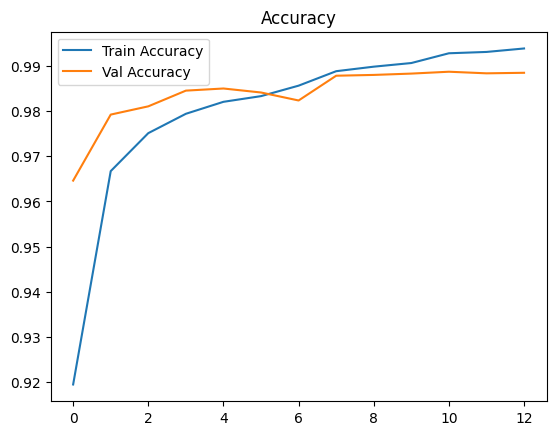

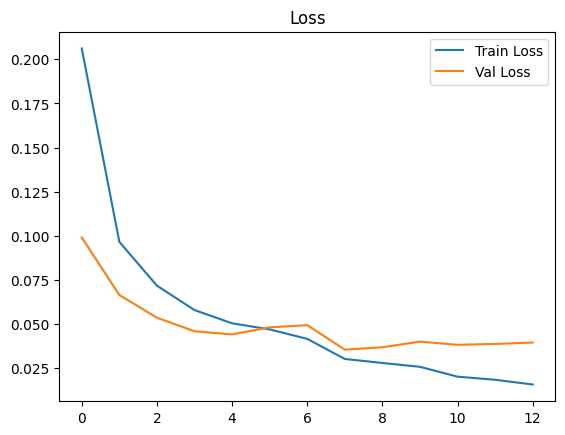

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred_probs = model.predict(test_data)
pred_labels = (pred_probs > 0.5).astype(int).reshape(-1)

true_labels = test_data.classes

cm = confusion_matrix(true_labels, pred_labels)
print(cm)

print(classification_report(true_labels, pred_labels, target_names=['awake', 'sleepy']))

531/531 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step
[[8545   46]
 [ 127 8263]]
              precision    recall  f1-score   support

       awake       0.99      0.99      0.99      8591
      sleepy       0.99      0.98      0.99      8390

    accuracy                           0.99     16981
   macro avg       0.99      0.99      0.99     16981
weighted avg       0.99      0.99      0.99     16981



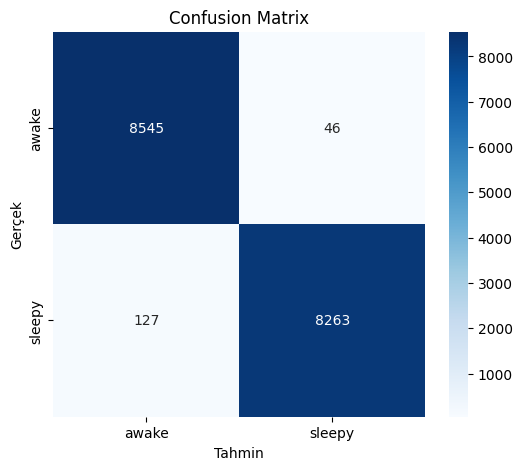

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['awake', 'sleepy'],
            yticklabels=['awake', 'sleepy'])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

Saving awake_1.png to awake_1.png
Saving awake_2.png to awake_2.png
Saving awake_3.png to awake_3.png
Saving sleepy_1.png to sleepy_1.png
Saving sleepy_2.png to sleepy_2.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128065 (\N{EYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


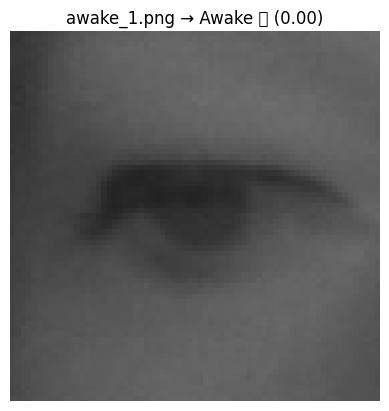

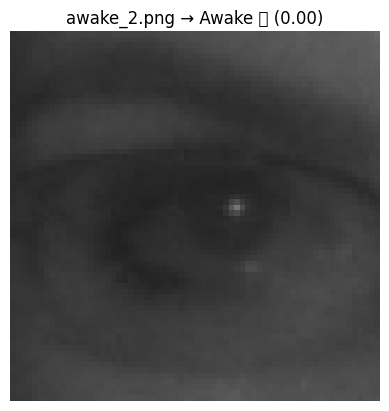

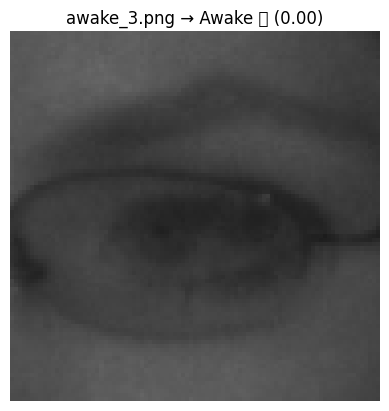

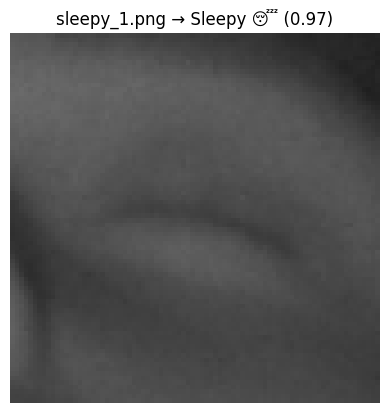

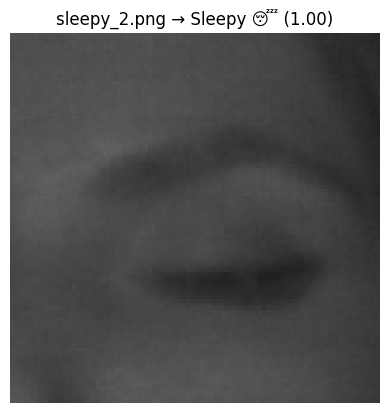

Mini Test Accuracy: 1.00 (5/5)


In [4]:
from tensorflow.keras.models import load_model
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Model yükle
model = load_model("/content/eye_drowsiness_cnn.h5")  # veya .keras

# 2️⃣ Foto yükle
uploaded = files.upload()

# 3️⃣ Tahmin + Görsel + Accuracy
correct = 0
total = 0

IMG_SIZE = 96

for file_name in uploaded.keys():
    img = cv2.imread(file_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    pred = model.predict(img_input, verbose=0)[0][0]

    # Tahmin etiketi
    if pred > 0.7:
        pred_label = 1
        pred_text = "Sleepy 😴"
    elif pred < 0.3:
        pred_label = 0
        pred_text = "Awake 👁️"
    else:
        pred_label = -1
        pred_text = "UNSURE 🤔"

    # Gerçek label (dosya isminden)
    if "awake" in file_name.lower():
        true_label = 0
    elif "sleepy" in file_name.lower():
        true_label = 1
    else:
        print(f"{file_name}: label bulunamadi (awake/sleepy yazmiyor)")
        continue

    # Accuracy hesapla
    if pred_label == true_label:
        correct += 1

    total += 1

    # Görsel göster
    plt.imshow(img_rgb)
    plt.title(f"{file_name} → {pred_text} ({pred:.2f})")
    plt.axis("off")
    plt.show()

# Sonuç
if total > 0:
    accuracy = correct / total
    print(f"Mini Test Accuracy: {accuracy:.2f} ({correct}/{total})")
else:
    print("Degerlendirilecek foto yok")

In [2]:
from tensorflow.keras.models import load_model

from google.colab import files


model = load_model("/content/eye_drowsiness_cnn.h5")

uploaded = files.upload()

Saving cizgili-gomlekli-genc-sakalli-adam_273609-5677.avif to cizgili-gomlekli-genc-sakalli-adam_273609-5677.avif
Saving depositphotos_26740233-stock-photo-businessman-with-eyes-closed.webp to depositphotos_26740233-stock-photo-businessman-with-eyes-closed.webp
Saving depositphotos_278981062-stock-photo-beautiful-young-woman-clean-fresh.webp to depositphotos_278981062-stock-photo-beautiful-young-woman-clean-fresh.webp
Saving stock-photo-close-view-girl-closed-eyes-freckles-face.webp to stock-photo-close-view-girl-closed-eyes-freckles-face.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128065 (\N{EYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


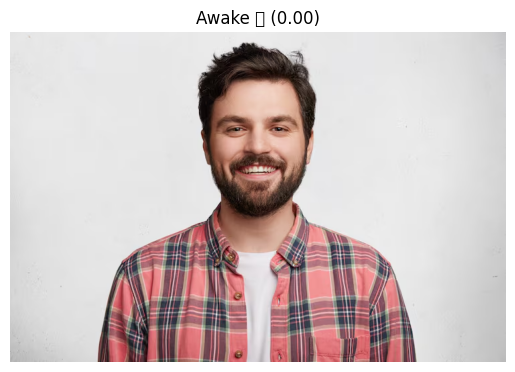

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


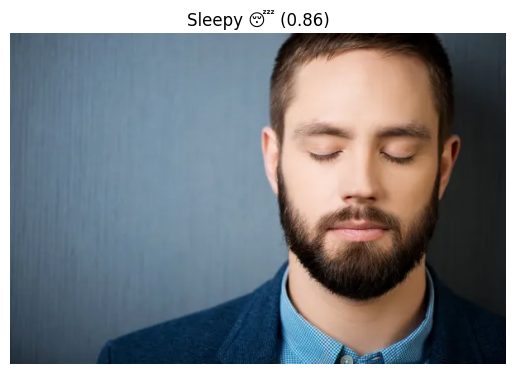

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


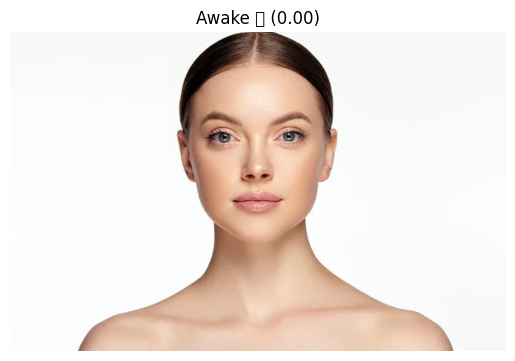

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


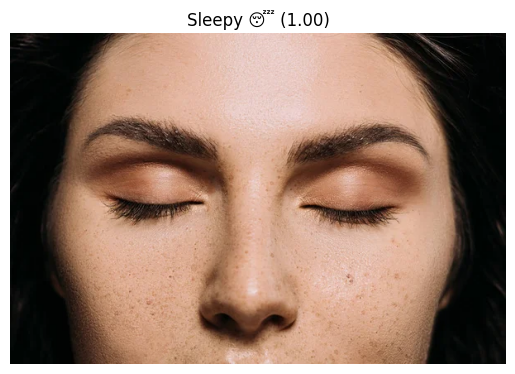

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96

for file_name in uploaded.keys():
    img = cv2.imread(file_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    pred = model.predict(img_input)[0][0]

    if pred > 0.7:
        label = "Sleepy 😴"
    elif pred < 0.3:
        label = "Awake 👁️"
    else:
        label = "UNSURE 🤔"

    plt.imshow(img_rgb)
    plt.title(f"{label} ({pred:.2f})")
    plt.axis("off")
    plt.show()

In [ ]:
model.save("/content/eye_drowsiness_cnn.h5")

In [ ]:
from google.colab import files
files.download("/content/eye_drowsiness_cnn.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>